In [ ]:
# Load Libraries and Iris Dataset
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
df = pd.concat([X, pd.Series(y, name='target')], axis=1)

print('Features shape: ', X.shape)
print('Target shape: ', y.shape)
print('\nFeature names: ', iris.feature_names)
print('Target names: ', iris.target_names.tolist())

df.head()

Features shape:  (150, 4)
Target shape:  (150,)

Feature names:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names:  ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


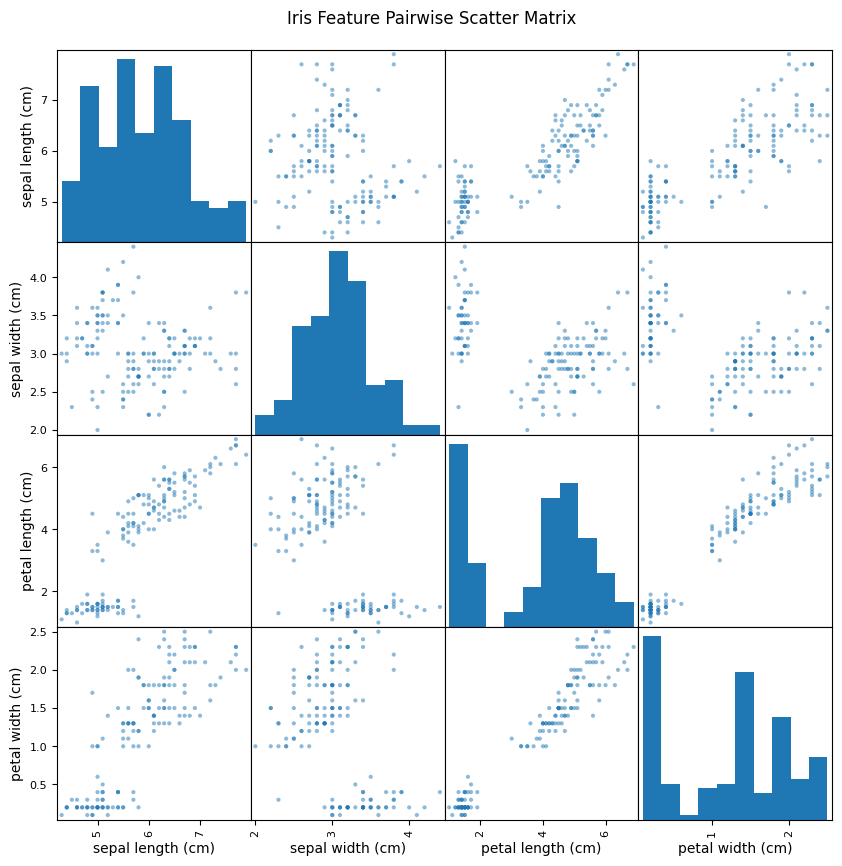

In [ ]:
# Visualize the Dataset
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

pd.options.display.max_columns = None

axes = scatter_matrix(X, figsize=(10,10), diagonal='hist')

plt.suptitle('Iris Feature Pairwise Scatter Matrix', y=0.92)
plt.show()

RandomForest Test Accuracy: 0.9000

Classification Report: 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


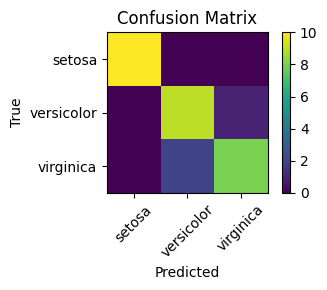

In [5]:
# Train a RandomForest Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"RandomForest Test Accuracy: {acc:.4f}\n")

print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(iris.target_names)), iris.target_names, rotation=45)
plt.yticks(range(len(iris.target_names)), iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [8]:
import os, joblib, pickle, json
from sklearn.metrics import accuracy_score

os.makedirs('models', exist_ok=True)
joblib.dump(rf_classifier, 'models/iris_model.joblib')

with open('models/iris_model.pickle', 'wb') as f:
    pickle.dump(rf_classifier, f)

try:
    acc_val = float(accuracy_score(y_test, y_pred))
except Exception:
    acc_val = None

model_info = {
    'model_type': 'RandomForestClassifier',
    'accuracy': acc_val,
    'feature_names': iris.feature_names,
    'target_names': iris.target_names.tolist()
}

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
feature_ranges = {
    'sepal_length': {'min': float(X['sepal length (cm)'].min()), 'max': float(X['sepal length (cm)'].max())},
    'sepal_width': {'min': float(X['sepal width (cm)'].min()), 'max': float(X['sepal width (cm)'].max())},
    'petal_length': {'min': float(X['petal length (cm)'].min()), 'max': float(X['petal length (cm)'].max())},
    'petal_width': {'min': float(X['petal width (cm)'].min()), 'max': float(X['petal width (cm)'].max())}
}
with open('models/feature_ranges.json', 'w') as f:
    json.dump(feature_ranges, f, indent=2)
print('Saved: models/iris_model.joblib, models/iris_model.pickle, models/model_info.json, models/feature_ranges.json')

Saved: models/iris_model.joblib, models/iris_model.pickle, models/model_info.json, models/feature_ranges.json
